# **Atividade 02**

Com base no que você aprendeu nas aulas anteriores no LABIN:

1.   Faça um notebook com o Google Colab
2.   Crop para excluir o piso quadriculado
3.   Divida a imagem nos canais R, G, B
4.   Obtenha e plote o histograma de cada imagem R, G, B
5.   Escreva no notebook o que você observou

Para entrega, envie por e-mail para juliana.fracarolli@feagri.unicamp.br e para Thiago t297177@dac.unicamp.br

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Image
%matplotlib inline

In [ ]:
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving CAM_0772.JPG to CAM_0772.JPG


# **READ**

imread 1: altura, largura, 3 canais

(1080, 1920, 3)

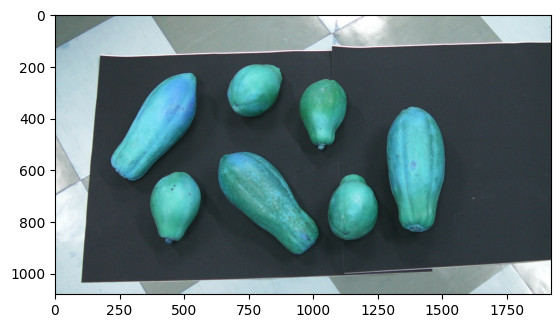

In [ ]:
# Ler a imagem em escala de CORES
img = cv2.imread("CAM_0772.JPG",1)
plt.imshow(img)
img.shape

# **INVERTER o B e o R**

(1080, 1920, 3)

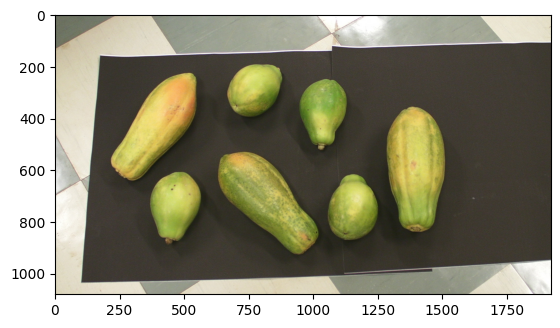

In [ ]:
img_reversa = img[:, :, ::-1] # todas as linhas, todas as colunas, inverte
plt.imshow(img_reversa)
img_reversa.shape # prova que está em BGR, 3 canais

# **CROP**

In [ ]:
altura, largura, canais = img_reversa.shape # Ignora o número de canais
print(altura, largura,canais)
print(img_reversa)

1080 1920 3
[[[111 117 103]
  [105 111  97]
  [102 108  94]
  ...
  [227 223 196]
  [227 223 196]
  [228 224 197]]

 [[111 118 102]
  [108 115  99]
  [105 112  96]
  ...
  [228 224 197]
  [228 224 197]
  [229 225 198]]

 [[105 112  96]
  [107 114  98]
  [104 111  95]
  ...
  [228 224 197]
  [228 224 197]
  [229 225 198]]

 ...

 [[215 209 183]
  [217 211 185]
  [218 212 186]
  ...
  [252 253 248]
  [249 250 245]
  [242 243 238]]

 [[216 210 186]
  [217 211 187]
  [219 213 189]
  ...
  [251 252 247]
  [249 250 245]
  [245 246 241]]

 [[218 212 190]
  [220 214 192]
  [221 215 193]
  ...
  [244 245 240]
  [247 248 243]
  [251 252 247]]]


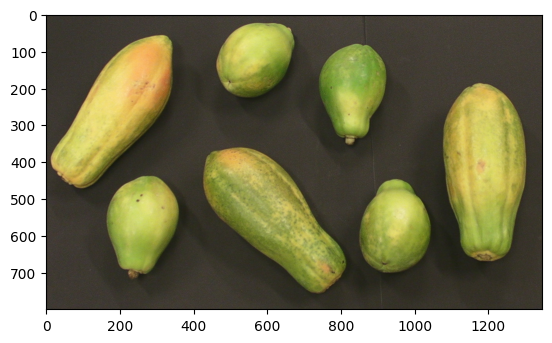

In [ ]:
img_copy = img_reversa.copy()
img_crop = img_copy[170:970,203:1550]
plt.imshow(img_crop, cmap='gray')

In [ ]:
img_crop.shape # prova que está em BGR, 3 canais

(800, 1347, 3)

A imagem uma vez feito o crop, ficou reduzida

# **IMAGEM DIVIDIDA**

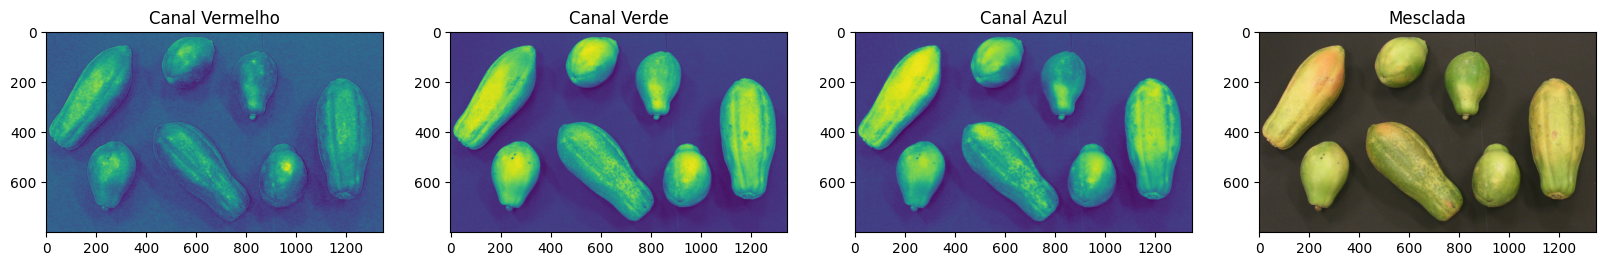

In [ ]:
# Dividir a imagem nas cores primárias
b,g,r = cv2.split(img_crop)

# Mostrar os canais
plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(r);plt.title("Canal Vermelho");
plt.subplot(142);plt.imshow(g);plt.title("Canal Verde");
plt.subplot(143);plt.imshow(b);plt.title("Canal Azul");

# Juntar os canais individuais em uma imagem RGB
imgMerged = cv2.merge((b,g,r))

# Mostrar a imagem mesclada
plt.subplot(144);plt.imshow(imgMerged[:,:,:]);plt.title("Mesclada");

Da pra observar que no canal vermelho fica muito "escura" a imagem em comparação com o canal verde, que as partes laranjas não destaca muito mas as amarelas sim. E no canal azul, ele é mais sensível aos cores amarelos e laranja, mas quando está verde, fica muito parecido com o canal verde.

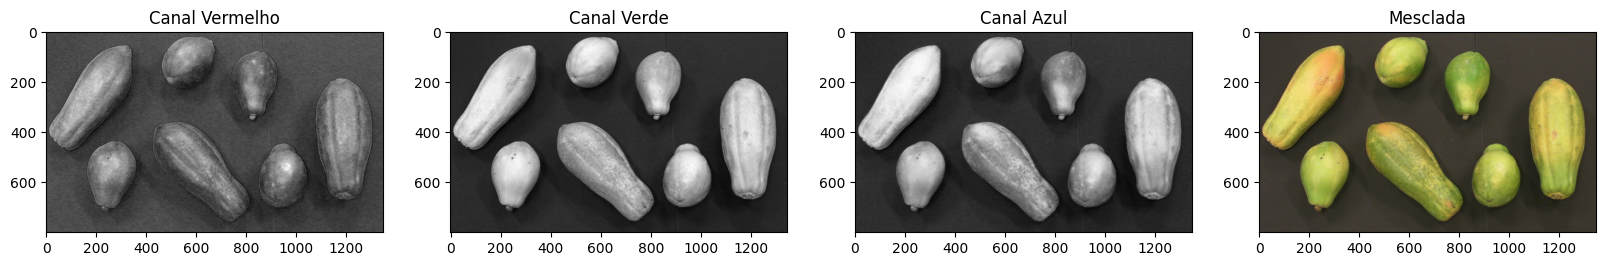

In [ ]:
# Dividir a imagem nas cores primárias
b,g,r = cv2.split(img_crop)

# Mostrar os canais
plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(r,cmap='gray');plt.title("Canal Vermelho");
plt.subplot(142);plt.imshow(g,cmap='gray');plt.title("Canal Verde");
plt.subplot(143);plt.imshow(b,cmap='gray');plt.title("Canal Azul");

# Juntar os canais individuais em uma imagem RGB
imgMerged = cv2.merge((b,g,r))

# Mostrar a imagem mesclada
plt.subplot(144);plt.imshow(imgMerged[:,:,:]);plt.title("Mesclada");

# **PLOTANDO HISTOGRAMAS**

/tmp/ipykernel_1009/1534810687.py:3: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(141);plt.hist(r.ravel(),256,[0,256]);plt.title("Canal Vermelho");
/tmp/ipykernel_1009/1534810687.py:4: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(142);plt.hist(g.ravel(),256,[0,256]);plt.title("Canal Verde");
/tmp/ipykernel_1009/1534810687.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(143);plt.hist(b.ravel(),256,[0,256]);plt.title("Canal Azul");
/tmp/ipykernel_1009/1534810687.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the pa

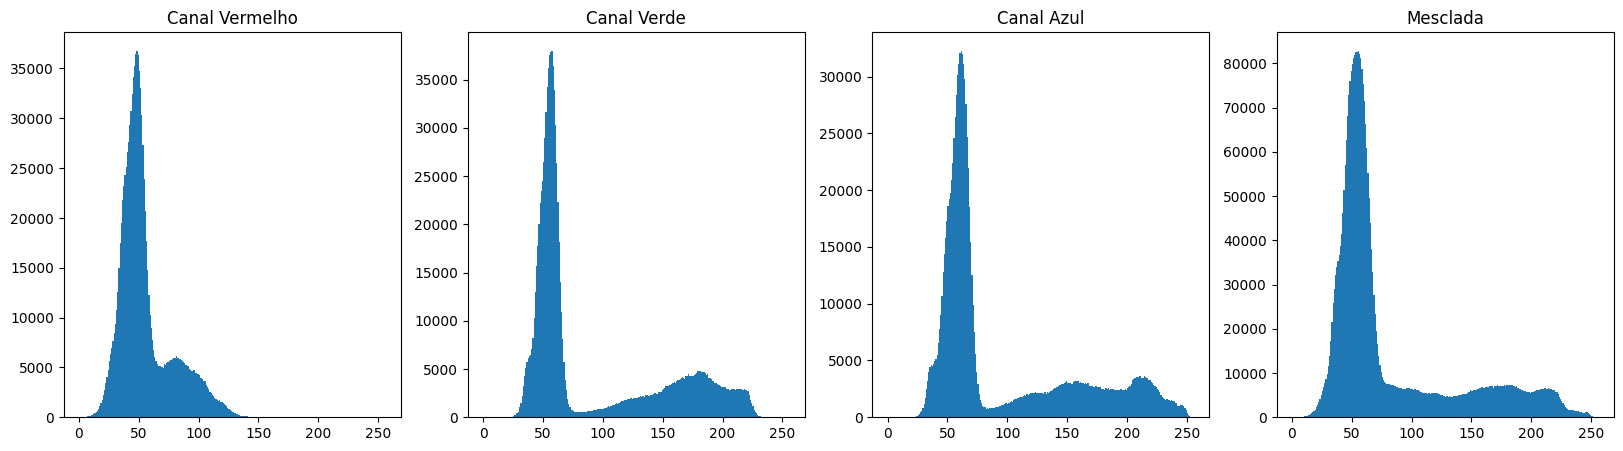

In [ ]:
# Mostrar os canais
plt.figure(figsize=[20,5])
plt.subplot(141);plt.hist(r.ravel(),256,[0,256]);plt.title("Canal Vermelho");
plt.subplot(142);plt.hist(g.ravel(),256,[0,256]);plt.title("Canal Verde");
plt.subplot(143);plt.hist(b.ravel(),256,[0,256]);plt.title("Canal Azul");

# Juntar os canais individuais em uma imagem RGB
imgMerged = cv2.merge((b,g,r))

# Mostrar a imagem mesclada
plt.subplot(144);plt.hist(imgMerged[:,:,:].ravel(),256,[0,256]);plt.title("Mesclada");


Achei muito legal as diferençãs encontradas em cada um dos hiostogramas, porque na imagem mesclada com os três canais, parece ter um modelo de mistura; mas quando estamos só olhando o canal vermelho, se reduz muito a dimensão de elementos mas a frequência continua igual de 0 a 70 aproximadamente, nos canais r, b, g.

Por outro lado, da pra perceber que no canal vermelho deixa de aparecer pixel, que no canal azul conseguem destacar-se os quais são os mais próximos da realidade.

## Imagem crop



/tmp/ipykernel_1009/668197381.py:2: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_crop.ravel(),256,[0,256]); plt.show()


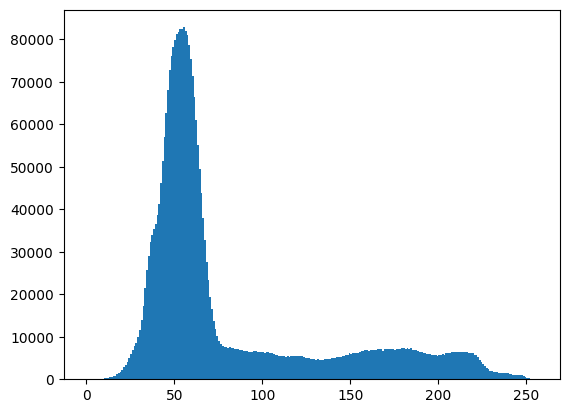

In [ ]:
hist,bins = np.histogram(img_crop.ravel(),256,[0,256])
plt.hist(img_crop.ravel(),256,[0,256]); plt.show()

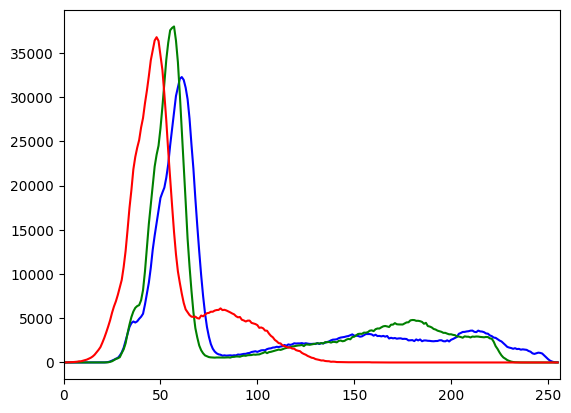

In [ ]:
color = ('b','g','r')
for i,col in enumerate(color):
 histr = cv2.calcHist([img_crop],[i],None,[256],[0,256])
 plt.plot(histr,color = col)
 plt.xlim([0,256])
plt.show()